# 03 · Build Patient Timelines
## ICU Virtual Patient Feed — Standardised timeline files for the 5 final patients

This notebook produces one `patient_<subject_id>` file per patient (`.parquet` if
pyarrow is healthy, `.csv` as automatic fallback — both work identically downstream).

| Column group | Columns | Source |
|---|---|---|
| Time axes | `timestamp`, `hours_since_admission` | ICU stay intime |
| Vitals | HR, MAP, SpO2, RR, Temp, SBP, DBP | `chartevents` → 15-min grid |
| Labs | creatinine, glucose, lactate, WBC, Hgb, K⁺, Na⁺, pH | `labevents` → LOCF |
| Drugs | `active_medications` — JSON list of running infusions | `inputevents` |
| ECG metadata | study_id, rhythm, HR, QTc, lead2 file path | `machine_measurements.csv` |
| Alarms | tachycardia, bradycardia, hypotension, SpO2 low, QTc prolonged | derived |

**Cache pattern:** heavy scans run once → saved as `.pkl` → every later run loads in seconds.
If you add or swap patients, delete `data/cache/nb03_*.pkl` and re-run Section 2.


In [9]:
import pandas as pd
import numpy as np
import json
import pickle
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from pathlib import Path

pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 30)
pd.set_option("display.float_format", "{:.2f}".format)
print("✅ Imports OK")


✅ Imports OK


In [10]:
CURRENT_DIR  = Path.cwd()
PROJECT_ROOT = CURRENT_DIR.parent if CURRENT_DIR.name == "scripts" else CURRENT_DIR

MIMIC_ROOT   = PROJECT_ROOT / "data" / "external" / "mimic-iv-3.1"
ECG_ROOT     = PROJECT_ROOT / "data" / "external" / "mimic-iv-ecg"
CACHE_DIR    = PROJECT_ROOT / "data" / "cache"
TIMELINE_DIR = PROJECT_ROOT / "data" / "processed" / "patient_timelines"

CACHE_DIR.mkdir(parents=True, exist_ok=True)
TIMELINE_DIR.mkdir(parents=True, exist_ok=True)

FINAL_PATIENTS = [
    {"subject_id": 16179553, "stay_id": 38224135, "hadm_id": 25052613,
     "label": "CVICU — mitral valve replacement + ECMO + cardiogenic shock"},
    {"subject_id": 17520318, "stay_id": 30682249, "hadm_id": 23431795,
     "label": "CVICU — CABG + AVR + septic shock, 7 drugs"},
    {"subject_id": 13269747, "stay_id": 31792549, "hadm_id": 25584074,
     "label": "CCU — AFib under rate control, 16 ECGs"},
    {"subject_id": 13408370, "stay_id": 30547595, "hadm_id": 27107260,
     "label": "CCU — anterior MI + VF arrest + AICD, 28 ECGs"},
    {"subject_id": 15906662, "stay_id": 36609534, "hadm_id": 24072687,
     "label": "CVICU — AMI + multi-vessel CABG + cardiogenic shock, 7 drugs"},
]

ALL_STAY_IDS = {p["stay_id"]   for p in FINAL_PATIENTS}
ALL_HADM_IDS = {p["hadm_id"]  for p in FINAL_PATIENTS}
ALL_SUBJ_IDS = {p["subject_id"] for p in FINAL_PATIENTS}

print(f"✅ {len(FINAL_PATIENTS)} final patients loaded")
for p in FINAL_PATIENTS:
    print(f"  · {p['subject_id']}  {p['label']}")


✅ 5 final patients loaded
  · 16179553  CVICU — mitral valve replacement + ECMO + cardiogenic shock
  · 17520318  CVICU — CABG + AVR + septic shock, 7 drugs
  · 13269747  CCU — AFib under rate control, 16 ECGs
  · 13408370  CCU — anterior MI + VF arrest + AICD, 28 ECGs
  · 15906662  CVICU — AMI + multi-vessel CABG + cardiogenic shock, 7 drugs


In [11]:
for f in ["nb03_ecgs.pkl", "nb03_labevents.pkl"]:
    p = CACHE_DIR / f
    if p.exists():
        p.unlink(); print("deleted", p.name)
    else:
        print("not found (ok)", f)
# KEEP nb03_chartevents.pkl, nb03_inputevents.pkl, nb03_icustays.pkl

not found (ok) nb03_ecgs.pkl
not found (ok) nb03_labevents.pkl


---
## Section 1 · Schema constants

In [12]:
VITAL_ITEMS = {
    220045: "heart_rate",
    220052: "map",
    225312: "map",
    220277: "spo2",
    223762: "temperature",
    223761: "temperature_f",
    220210: "respiratory_rate",
    220179: "sbp",
    220050: "sbp",
    220180: "dbp",
    220051: "dbp",
}

LAB_ITEMS = {
    50912: "creatinine",
    50931: "glucose",
    50813: "lactate",
    51301: "wbc",
    51222: "hemoglobin",
    50971: "potassium",
    50983: "sodium",
    50820: "ph",
    51003: "troponin",
}

VITAL_LOCF_LIMIT = 8

LAB_LOCF_LIMITS = {
    "creatinine": 96,
    "glucose":    32,
    "lactate":    32,
    "wbc":        96,
    "hemoglobin": 96,
    "potassium":  96,
    "sodium":     96,
    "ph":         32,
    "troponin":   48,
}

ALARM_RULES = {
    "alarm_tachycardia":   lambda df: df["heart_rate"]         > 120,
    "alarm_bradycardia":   lambda df: df["heart_rate"]         < 45,
    "alarm_hypotension":   lambda df: df["map"]                < 65,
    "alarm_spo2_low":      lambda df: df["spo2"]               < 92,
    "alarm_qtc_prolonged": lambda df: df["ecg_machine_qtc_ms"] > 500,
}

GRID_FREQ = "15min"

print("✅ Schema constants defined")
print(f"   Vitals: {len(set(VITAL_ITEMS.values()))}  |  Labs: {len(LAB_ITEMS)}  |  Alarms: {len(ALARM_RULES)}")


✅ Schema constants defined
   Vitals: 8  |  Labs: 9  |  Alarms: 5


---
## Section 2 · Smart cache

Each step saves immediately after completion. If the notebook crashes mid-way,
only the failed step re-runs — completed steps load from `.pkl` in seconds.

```
data/cache/
├── nb03_icustays.pkl       instant
├── nb03_chartevents.pkl    slow (~15-25 min first run)
├── nb03_labevents.pkl      medium (~2-5 min)
├── nb03_inputevents.pkl    medium (~2-5 min)
└── nb03_ecgs.pkl           instant
```


In [13]:
NB03_CACHE = {
    "icustays":    CACHE_DIR / "nb03_icustays.pkl",
    "chartevents": CACHE_DIR / "nb03_chartevents.pkl",
    "labevents":   CACHE_DIR / "nb03_labevents.pkl",
    "inputevents": CACHE_DIR / "nb03_inputevents.pkl",
    "ecgs":        CACHE_DIR / "nb03_ecgs.pkl",
}

def _cache_save(df, path):
    with open(path, "wb") as f:
        pickle.dump(df, f, protocol=4)

def _cache_load(path):
    with open(path, "rb") as f:
        return pickle.load(f)

def _load_or_build(key, build_fn):
    path = NB03_CACHE[key]
    if path.exists():
        df = _cache_load(path)
        print(f"  ✅ [{key:14s}] from cache  ({len(df):,} rows)")
        return df
    print(f"  ⏳ [{key:14s}] not cached — scanning...")
    df = build_fn()
    _cache_save(df, path)
    mb = path.stat().st_size / 1_048_576
    print(f"  💾 [{key:14s}] saved  ({mb:.1f} MB, {len(df):,} rows)")
    return df


# ── Step 1: ICU stays ─────────────────────────────────────────────────────────
def _build_icustays():
    df = pd.read_csv(MIMIC_ROOT / "icu" / "icustays.csv.gz",
                     parse_dates=["intime", "outtime"])
    return df[df["stay_id"].isin(ALL_STAY_IDS)].copy()

stays_c = _load_or_build("icustays", _build_icustays)


# ── Step 2: chartevents ───────────────────────────────────────────────────────
def _build_chartevents():
    all_vital_ids = set(VITAL_ITEMS.keys())
    cc = []
    for i, chunk in enumerate(pd.read_csv(
            MIMIC_ROOT / "icu" / "chartevents.csv.gz",
            usecols=["subject_id","stay_id","itemid","charttime","valuenum","valueuom"],
            parse_dates=["charttime"], chunksize=5_000_000)):
        sub = chunk[chunk["stay_id"].isin(ALL_STAY_IDS) & chunk["itemid"].isin(all_vital_ids)]
        if len(sub): cc.append(sub)
        if (i + 1) % 5 == 0:
            print(f"    chunk {i+1}, {sum(len(x) for x in cc):,} rows so far")
    return pd.concat(cc, ignore_index=True)

chart_c = _load_or_build("chartevents", _build_chartevents)


# ── Step 3: labevents ─────────────────────────────────────────────────────────
def _build_labevents():
    all_lab_ids = set(LAB_ITEMS.keys())
    lc = []
    for chunk in pd.read_csv(
            MIMIC_ROOT / "hosp" / "labevents.csv.gz",
            usecols=["subject_id","hadm_id","itemid","charttime","valuenum","valueuom"],
            parse_dates=["charttime"], chunksize=3_000_000):
        sub = chunk[chunk["hadm_id"].isin(ALL_HADM_IDS) & chunk["itemid"].isin(all_lab_ids)]
        if len(sub): lc.append(sub)
    return pd.concat(lc, ignore_index=True)

lab_c = _load_or_build("labevents", _build_labevents)


# ── Step 4: inputevents ───────────────────────────────────────────────────────
def _build_inputevents():
    d_items = pd.read_csv(MIMIC_ROOT / "icu" / "d_items.csv.gz",
                           usecols=["itemid","label","param_type"])
    drug_ids = set(d_items[d_items["param_type"].isin(["Solution","Drug"])]["itemid"])
    if not drug_ids:
        print("    ⚠️  param_type filter matched 0 — loading all inputevents for these stays")
        drug_ids = None
    ic = []
    for chunk in pd.read_csv(
            MIMIC_ROOT / "icu" / "inputevents.csv.gz",
            usecols=["subject_id","stay_id","itemid","starttime","endtime",
                     "rate","rateuom","amount","amountuom"],
            parse_dates=["starttime","endtime"], chunksize=2_000_000):
        sub = (chunk[chunk["stay_id"].isin(ALL_STAY_IDS) & chunk["itemid"].isin(drug_ids)]
               if drug_ids else chunk[chunk["stay_id"].isin(ALL_STAY_IDS)])
        if len(sub): ic.append(sub)
    if not ic:
        raise RuntimeError(f"inputevents: 0 rows for stay_ids {ALL_STAY_IDS}")
    result = pd.concat(ic, ignore_index=True)
    return result.merge(d_items[["itemid","label"]], on="itemid", how="left")

input_c = _load_or_build("inputevents", _build_inputevents)


# ── Step 5: ECG record list + machine measurements ────────────────────────────
# FIX: machine_measurements.csv also contains a subject_id column.
# Dropping it from meas before merging prevents subject_id_x / subject_id_y
# from appearing in the combined table and breaking downstream lookups.
def _build_ecgs():
    ecg_list = pd.read_csv(ECG_ROOT / "record_list.csv", parse_dates=["ecg_time"])
    ecg_list = ecg_list[ecg_list["subject_id"].isin(ALL_SUBJ_IDS)].copy()

    meas_path = ECG_ROOT / "machine_measurements.csv"
    if not meas_path.exists():
        print(f"    ⚠️  {meas_path} not found — ECG machine columns will be empty")
        return ecg_list

    meas = pd.read_csv(meas_path, low_memory=False)

    # Drop any columns from meas that already exist in ecg_list (except the join key)
    # This prevents _x / _y suffixes on subject_id, ecg_time, path, etc.
    cols_to_drop = [c for c in meas.columns if c in ecg_list.columns and c != "study_id"]
    if cols_to_drop:
        meas = meas.drop(columns=cols_to_drop)

    # Cast object columns to str to avoid mixed-type serialisation issues
    for col in meas.columns[meas.dtypes == object]:
        meas[col] = meas[col].astype(str).replace("nan", pd.NA)

    combined = ecg_list.merge(meas, on="study_id", how="left")


    for col in combined.columns[combined.dtypes == object]:
        combined[col] = combined[col].astype(str).replace("nan", pd.NA)

    # ── derive machine measurements from raw interval fields (all in ms) ──
    def _num(c):
        return pd.to_numeric(combined[c], errors="coerce") if c in combined.columns else np.nan
    rr = _num("rr_interval")
    combined["heart_rate"]   = np.where(rr > 0, 60000.0 / rr, np.nan)
    combined["pr_interval"]  = _num("qrs_onset") - _num("p_onset")
    combined["qrs_duration"] = _num("qrs_end")   - _num("qrs_onset")
    combined["qt_interval"]  = _num("t_end")     - _num("qrs_onset")
    combined["qtc_interval"] = np.where(rr > 0, combined["qt_interval"] / np.sqrt(rr / 1000.0), np.nan)
    _rep = [c for c in combined.columns if c.startswith("report_")]
    combined["report"] = (
        combined[_rep].apply(
            lambda r: "; ".join(str(x) for x in r
                                if pd.notna(x) and str(x) not in ("nan", "<NA>", "None")),
            axis=1).replace("", pd.NA)
        if _rep else pd.NA
    )
    return combined

ecgs_c = _load_or_build("ecgs", _build_ecgs)


# ── Parquet check ─────────────────────────────────────────────────────────────
print()
try:
    _t = pd.DataFrame({"a": [1, 2]})
    _t.to_parquet(CACHE_DIR / "_test.parquet", index=False)
    (CACHE_DIR / "_test.parquet").unlink()
    PARQUET_OK = True
    print("✅ Parquet OK — timelines will be saved as .parquet")
except Exception as _e:
    PARQUET_OK = False
    print(f"⚠️  Parquet unavailable ({type(_e).__name__}) — timelines will be saved as .csv")
    print("   Fix later: pip install --upgrade pyarrow  then restart kernel")

print()
print("✅ All 5 cache steps complete.")
print(f"   chartevents:  {len(chart_c):,} rows")
print(f"   labevents:    {len(lab_c):,} rows")
print(f"   inputevents:  {len(input_c):,} rows")
print(f"   ECGs + meas:  {len(ecgs_c):,} rows")
print(f"   ecgs_c cols:  {ecgs_c.columns.tolist()}")


  ✅ [icustays      ] from cache  (5 rows)
  ✅ [chartevents   ] from cache  (18,246 rows)
  ⏳ [labevents     ] not cached — scanning...
  💾 [labevents     ] saved  (0.1 MB, 2,244 rows)
  ✅ [inputevents   ] from cache  (8,208 rows)
  ⏳ [ecgs          ] not cached — scanning...
  💾 [ecgs          ] saved  (0.1 MB, 98 rows)

✅ Parquet OK — timelines will be saved as .parquet

✅ All 5 cache steps complete.
   chartevents:  18,246 rows
   labevents:    2,244 rows
   inputevents:  8,208 rows
   ECGs + meas:  98 rows
   ecgs_c cols:  ['subject_id', 'study_id', 'file_name', 'ecg_time', 'path', 'cart_id', 'report_0', 'report_1', 'report_2', 'report_3', 'report_4', 'report_5', 'report_6', 'report_7', 'report_8', 'report_9', 'report_10', 'report_11', 'report_12', 'report_13', 'report_14', 'report_15', 'report_16', 'report_17', 'bandwidth', 'filtering', 'rr_interval', 'p_onset', 'p_end', 'qrs_onset', 'qrs_end', 't_end', 'p_axis', 'qrs_axis', 't_axis', 'heart_rate', 'pr_interval', 'qrs_duration', 'q

---
## Section 3 · Helper functions

Six focused functions — one per data modality plus alarms.


In [14]:
# ── Save / load helpers (respects PARQUET_OK flag) ───────────────────────────
def save_timeline(df, subject_id):
    if PARQUET_OK:
        path = TIMELINE_DIR / f"patient_{subject_id}.parquet"
        df.to_parquet(path, index=False)
    else:
        path = TIMELINE_DIR / f"patient_{subject_id}.csv"
        df.to_csv(path, index=False)
    return path

def read_timeline(subject_id):
    parquet_path = TIMELINE_DIR / f"patient_{subject_id}.parquet"
    csv_path     = TIMELINE_DIR / f"patient_{subject_id}.csv"
    if parquet_path.exists():
        return pd.read_parquet(parquet_path)
    if csv_path.exists():
        return pd.read_csv(csv_path, parse_dates=["timestamp"])
    raise FileNotFoundError(f"No timeline file found for subject {subject_id}")


# ── 1. Grid ───────────────────────────────────────────────────────────────────
def build_grid(intime, outtime):
    return pd.date_range(start=intime.floor(GRID_FREQ),
                         end=outtime.ceil(GRID_FREQ),
                         freq=GRID_FREQ)


# ── 2. Vitals ─────────────────────────────────────────────────────────────────
def resample_vitals(chart_stay, grid):
    df = chart_stay.copy()
    df["vital"] = df["itemid"].map(VITAL_ITEMS)
    df = df.dropna(subset=["vital", "valuenum"])

    # Fahrenheit → Celsius
    mask_f = df["vital"] == "temperature_f"
    df.loc[mask_f, "valuenum"] = (df.loc[mask_f, "valuenum"] - 32) * 5 / 9
    df.loc[mask_f, "vital"] = "temperature"

    df = df[df["valuenum"] > 0]

    if df.empty:
        return pd.DataFrame(index=grid)

    pivot = (df.set_index("charttime")
               .groupby("vital")["valuenum"]
               .resample(GRID_FREQ)
               .median()
               .unstack(level=0))

    pivot = pivot.reindex(pivot.index.union(grid)).sort_index()
    pivot = pivot.ffill(limit=VITAL_LOCF_LIMIT)
    return pivot.reindex(grid)


# ── 3. Labs ───────────────────────────────────────────────────────────────────
def resample_labs(lab_patient, grid, hadm_id, intime, outtime):
    df = lab_patient[
        (lab_patient["hadm_id"] == hadm_id) &
        (lab_patient["charttime"] >= intime) &
        (lab_patient["charttime"] <= outtime)
    ].copy()
    df["lab"] = df["itemid"].map(LAB_ITEMS)
    df = df.dropna(subset=["lab", "valuenum"])
    df = df[df["valuenum"] > 0]

    if df.empty:
        return pd.DataFrame(index=grid)

    pivot = (df.set_index("charttime")
               .groupby("lab")["valuenum"]
               .resample(GRID_FREQ)
               .median()
               .unstack(level=0))

    pivot = pivot.reindex(pivot.index.union(grid)).sort_index()
    for col in pivot.columns:
        pivot[col] = pivot[col].ffill(limit=LAB_LOCF_LIMITS.get(col, 96))
    return pivot.reindex(grid)


# ── 4. Active drugs ───────────────────────────────────────────────────────────
def build_active_drugs(input_stay, grid):
    df = input_stay.copy()
    df["endtime"] = df["endtime"].fillna(df["starttime"] + pd.Timedelta("15min"))

    result = []
    for t in grid:
        active = df[(df["starttime"] <= t) & (df["endtime"] >= t)]
        seen = {}
        for _, row in active.iterrows():
            name = str(row["label"]) if pd.notna(row.get("label")) else "Unknown"
            rate = float(row["rate"]) if pd.notna(row.get("rate")) and row["rate"] > 0 else None
            unit = str(row["rateuom"]) if pd.notna(row.get("rateuom")) else None
            if name not in seen or (rate is not None and (seen[name].get("rate") or 0) < rate):
                entry = {"drug": name}
                if rate is not None:
                    entry["rate"] = round(rate, 4)
                    entry["unit"] = unit
                seen[name] = entry
        result.append(json.dumps(list(seen.values())))
    return result


# ── 5. ECG metadata ───────────────────────────────────────────────────────────
# FIX: ecgs_stay already contains all machine measurement columns (merged in
# _build_ecgs). We must NOT re-merge meas here — doing so would cause _x/_y
# column suffixes and break the ecg_time → timestamp rename that merge_asof needs.
def attach_ecg_metadata(grid_df, ecgs_stay, subject_id):
    ecg_cols = ["ecg_study_id","ecg_machine_rhythm","ecg_machine_hr",
                "ecg_machine_pr_ms","ecg_machine_qrs_ms","ecg_machine_qtc_ms","ecg_lead2_file"]

    if ecgs_stay.empty:
        for col in ecg_cols:
            grid_df[col] = np.nan
        return grid_df

    right = (ecgs_stay
             .copy()
             .sort_values("ecg_time")
             .reset_index(drop=True)
             .rename(columns={"ecg_time": "timestamp"}))

    left = pd.DataFrame({"timestamp": pd.to_datetime(grid_df["timestamp"])})
    right["timestamp"] = pd.to_datetime(right["timestamp"])

    merged = pd.merge_asof(left, right, on="timestamp", direction="backward")

    # Safe column extractor — always returns an array of the correct length.
    # If the column is missing (machine_measurements had no data for this patient),
    # fills with NaN instead of returning a length-0 Series.
    n = len(merged)
    def _col(name, fill=np.nan):
        if name in merged.columns:
            return merged[name].values
        return np.full(n, fill)

    def lead2_path(row):
        sid_val = row.get("study_id")
        if pd.isna(sid_val) or str(sid_val) in ("nan", "None", "<NA>"):
            return np.nan
        return f"ecg_waveforms/p{subject_id}_s{sid_val}_lead2.npy"

    grid_df["ecg_study_id"]       = _col("study_id")
    grid_df["ecg_machine_rhythm"] = _col("report")
    grid_df["ecg_machine_hr"]     = _col("heart_rate")
    grid_df["ecg_machine_pr_ms"]  = _col("pr_interval")
    grid_df["ecg_machine_qrs_ms"] = _col("qrs_duration")
    grid_df["ecg_machine_qtc_ms"] = _col("qtc_interval")
    grid_df["ecg_lead2_file"]     = merged.apply(lead2_path, axis=1).values
    return grid_df


# ── 6. Alarms ─────────────────────────────────────────────────────────────────
def derive_alarms(df):
    for alarm, rule in ALARM_RULES.items():
        try:
            df[alarm] = rule(df).fillna(False)
        except KeyError:
            df[alarm] = False
    return df


print("✅ All helper functions defined")


✅ All helper functions defined


---
## Section 4 · Build timelines

Loops over the 5 patients. Each timeline is saved immediately after it's built —
if the cell crashes on patient 4, patients 1-3 are already on disk.


In [ ]:
summary = []

for patient in FINAL_PATIENTS:
    sid     = patient["subject_id"]
    stay_id = patient["stay_id"]
    hadm_id = patient["hadm_id"]
    label   = patient["label"]

    print(f"\n{'─'*60}")
    print(f"Building:  subject {sid}")
    print(f"  {label}")

    # Stay metadata
    stay = stays_c[stays_c["stay_id"] == stay_id].iloc[0]
    intime, outtime = stay["intime"], stay["outtime"]

    # 15-min grid
    grid = build_grid(intime, outtime)
    print(f"  Grid: {len(grid)} rows  ({intime.date()} → {outtime.date()})")

    # Vitals
    vitals_df = resample_vitals(chart_c[chart_c["stay_id"] == stay_id], grid)

    # Labs
    labs_df = resample_labs(lab_c, grid, hadm_id, intime, outtime)

    # Active drugs
    active_drugs_col = build_active_drugs(
        input_c[input_c["stay_id"] == stay_id], grid)

    # ECG window filter
    ecgs_stay = ecgs_c[
        (ecgs_c["subject_id"] == sid) &
        (ecgs_c["ecg_time"] >= intime - pd.Timedelta(hours=48)) &
        (ecgs_c["ecg_time"] <= outtime + pd.Timedelta(hours=48))
    ].copy()

    # Assemble timeline
    timeline = pd.DataFrame({"timestamp": grid})
    timeline["hours_since_admission"] = (
        (timeline["timestamp"] - intime).dt.total_seconds() / 3600
    ).round(4)

    for col in vitals_df.columns:
        timeline[col] = vitals_df[col].values
    for col in labs_df.columns:
        timeline[col] = labs_df[col].values

    timeline["active_medications"] = active_drugs_col

    # Guarantee all expected columns exist (fill with NaN if data was absent)
    for col in ["heart_rate","map","spo2","temperature","respiratory_rate","sbp","dbp"]:
        if col not in timeline.columns:
            timeline[col] = np.nan
    for col in ["creatinine","glucose","lactate","wbc","hemoglobin","potassium","sodium","ph","troponin"]:
        if col not in timeline.columns:
            timeline[col] = np.nan

    # strip any float-rendered study_id from the ECG path  (s45151939.0 -> s45151939)
    if "ecg_lead2_file" in timeline.columns:
        timeline["ecg_lead2_file"] = (
            timeline["ecg_lead2_file"].astype("string")
            .str.replace(r"\.0(_lead2\.npy)$", r"\1", regex=True)
        )

    # ECG metadata (note: no meas argument — ecgs_stay already contains it)
    timeline = attach_ecg_metadata(timeline, ecgs_stay, sid)

    vital_cols = ["heart_rate","map","spo2","respiratory_rate","temperature","sbp","dbp"]
    present = [c for c in vital_cols if c in timeline.columns]
    timeline[present] = timeline[present].bfill(limit=8)   # fill up to 2h of leading gap


    # Alarm flags
    timeline = derive_alarms(timeline)

    # Metadata columns
    timeline["surgery_phase"] = np.nan
    timeline.insert(0, "subject_id", sid)
    timeline.insert(1, "stay_id", stay_id)
    timeline.insert(2, "label", label)

    # Save
    out_path = save_timeline(timeline, sid)

    # Stats
    n_ecgs      = ecgs_stay["study_id"].nunique()
    drug_rows   = sum(1 for x in active_drugs_col if x != "[]")
    alarm_count = timeline[[c for c in timeline.columns if c.startswith("alarm_")]].sum().sum()

    print(f"  Vitals: HR {timeline['heart_rate'].notna().mean():.0%} | "
          f"MAP {timeline['map'].notna().mean():.0%} | "
          f"SpO2 {timeline['spo2'].notna().mean():.0%}")
    print(f"  ECGs: {n_ecgs}  |  drug-active rows: {drug_rows}/{len(timeline)}  "
          f"|  alarms: {int(alarm_count)}")
    print(f"  Saved → {out_path.name}  ({out_path.stat().st_size/1024:.0f} KB)")

    summary.append({"subject_id": sid, "rows": len(timeline), "ecgs": n_ecgs,
                    "drug_rows": drug_rows, "alarm_events": int(alarm_count),
                    "file_kb": round(out_path.stat().st_size / 1024, 1)})

print(f"\n{'='*60}")
print("✅ All 5 timelines built.")
pd.DataFrame(summary)



────────────────────────────────────────────────────────────
Building:  subject 16179553
  CVICU — mitral valve replacement + ECMO + cardiogenic shock
  Grid: 1692 rows  (2162-11-01 → 2162-11-19)
  Vitals: HR 98% | MAP 98% | SpO2 86%
  ECGs: 7  |  drug-active rows: 1649/1692  |  alarms: 1362
  Saved → patient_16179553.parquet  (109 KB)

────────────────────────────────────────────────────────────
Building:  subject 17520318
  CVICU — CABG + AVR + septic shock, 7 drugs
  Grid: 1720 rows  (2170-03-02 → 2170-03-20)
  Vitals: HR 98% | MAP 98% | SpO2 97%
  ECGs: 7  |  drug-active rows: 1669/1720  |  alarms: 2474
  Saved → patient_17520318.parquet  (98 KB)

────────────────────────────────────────────────────────────
Building:  subject 13269747
  CCU — AFib under rate control, 16 ECGs
  Grid: 1626 rows  (2160-06-24 → 2160-07-11)
  Vitals: HR 99% | MAP 86% | SpO2 99%
  ECGs: 16  |  drug-active rows: 1609/1626  |  alarms: 1800
  Saved → patient_13269747.parquet  (80 KB)

─────────────────────

,subject_id,rows,ecgs,drug_rows,alarm_events,file_kb
0,16179553,1692,7,1649,1362,109.10
1,17520318,1720,7,1669,2474,98.00
2,13269747,1626,16,1609,1800,80.00
3,13408370,2389,28,2152,1003,91.30
4,15906662,1931,8,1902,1085,99.30


---
## Section 5 · Validation

Checks schema, vital coverage, JSON validity of drug column, and no duplicate timestamps.


In [16]:
REQUIRED_COLS = [
    "subject_id", "stay_id", "timestamp", "hours_since_admission",
    "heart_rate", "map", "spo2", "respiratory_rate", "temperature",
    "creatinine", "glucose", "active_medications",
    "ecg_study_id", "ecg_lead2_file",
    "alarm_tachycardia", "alarm_hypotension",
]

def bar(cov, width=20):
    n = round(cov * width)
    return "█" * n + "░" * (width - n) + f" {cov:5.1%}"

all_ok = True
for patient in FINAL_PATIENTS:
    sid = patient["subject_id"]
    try:
        df = read_timeline(sid)
    except FileNotFoundError as e:
        print(f"\n❌ subject {sid}: {e}")
        all_ok = False
        continue

    issues = []
    missing = [c for c in REQUIRED_COLS if c not in df.columns]
    if missing: issues.append(f"missing cols: {missing}")
    dupes = df["timestamp"].duplicated().sum()
    if dupes: issues.append(f"{dupes} duplicate timestamps")
    try:
        for v in df["active_medications"].dropna().head(20): json.loads(v)
    except Exception as e:
        issues.append(f"active_medications JSON error: {e}")
    for vital in ["heart_rate","map","spo2"]:
        cov = df[vital].notna().mean() if vital in df else 0
        if cov < 0.5: issues.append(f"{vital} coverage {cov:.0%} < 50%")

    status = "✅" if not issues else "⚠️ "
    if issues: all_ok = False

    print(f"\n{status} subject {sid}  ({len(df)} rows)")
    for col, name in [("heart_rate","HR"),("map","MAP"),("spo2","SpO2"),
                      ("creatinine","Creat"),("glucose","Gluc"),("ecg_study_id","ECG")]:
        cov = df[col].notna().mean() if col in df else 0.0
        print(f"   {name:8s}  {bar(cov)}")
    for iss in issues:
        print(f"   ⚠️  {iss}")

print(f"\n{'='*60}")
print("✅ All timelines valid." if all_ok else "⚠️  Issues above need attention.")



✅ subject 16179553  (1692 rows)
   HR        ████████████████████ 97.9%
   MAP       ████████████████████ 97.9%
   SpO2      █████████████████░░░ 86.4%
   Creat     ████████████████████ 99.6%
   Gluc      ███████████████░░░░░ 72.6%
   ECG       ████████████████████ 100.0%

✅ subject 17520318  (1720 rows)
   HR        ████████████████████ 98.1%
   MAP       ████████████████████ 97.6%
   SpO2      ███████████████████░ 97.4%
   Creat     ████████████████████ 98.7%
   Gluc      █████████████░░░░░░░ 66.0%
   ECG       ████████████████████ 100.0%

✅ subject 13269747  (1626 rows)
   HR        ████████████████████ 99.4%
   MAP       █████████████████░░░ 86.4%
   SpO2      ████████████████████ 98.7%
   Creat     ████████████████████ 97.6%
   Gluc      ██████████░░░░░░░░░░ 49.9%
   ECG       ████████████████████ 100.0%

✅ subject 13408370  (2389 rows)
   HR        ████████████████████ 99.6%
   MAP       ███████████████░░░░░ 73.4%
   SpO2      ████████████████████ 99.6%
   Creat     ████████████

---
## Section 6 · Quick visual check

HR and MAP on the 15-min grid. Purple lines = ECG record times.


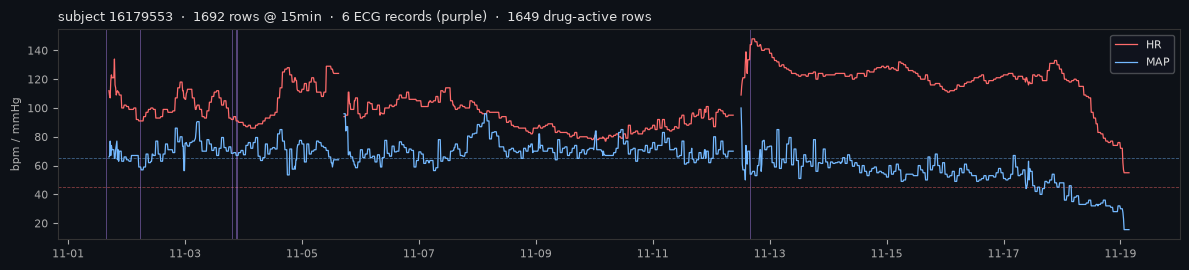

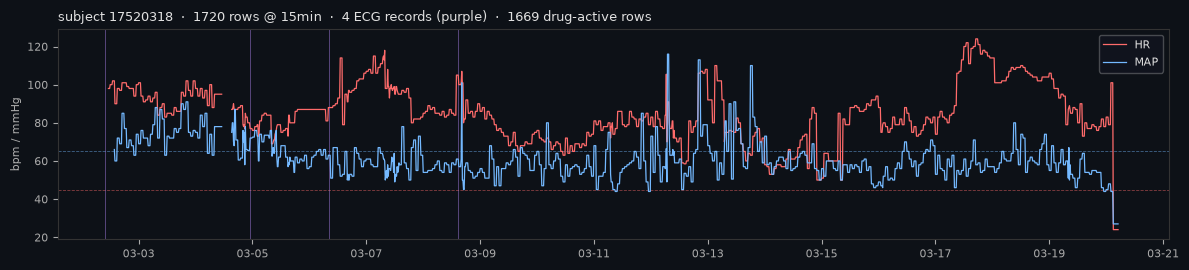

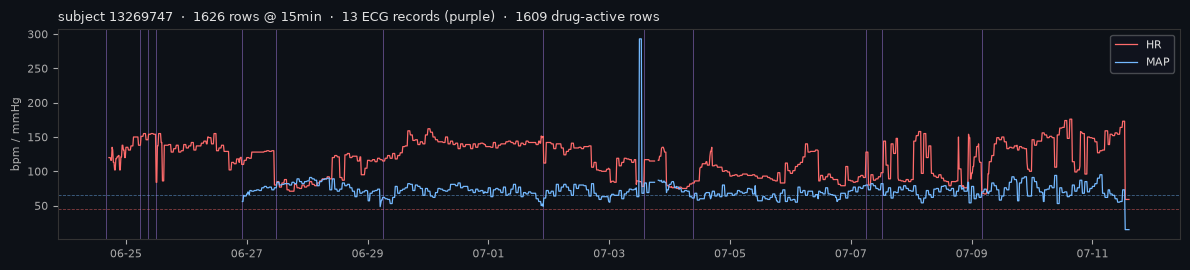

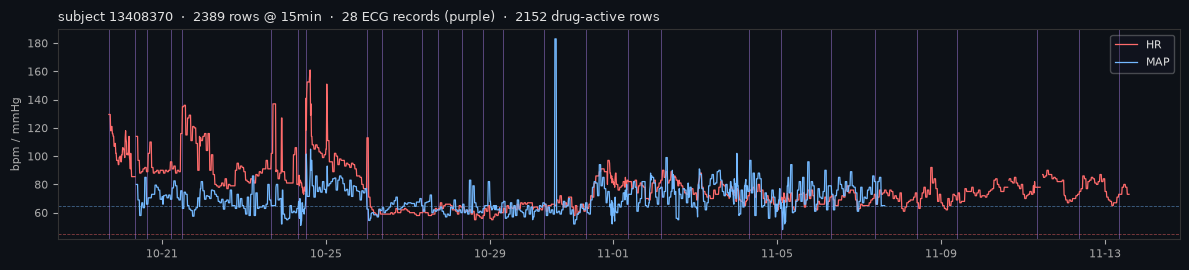

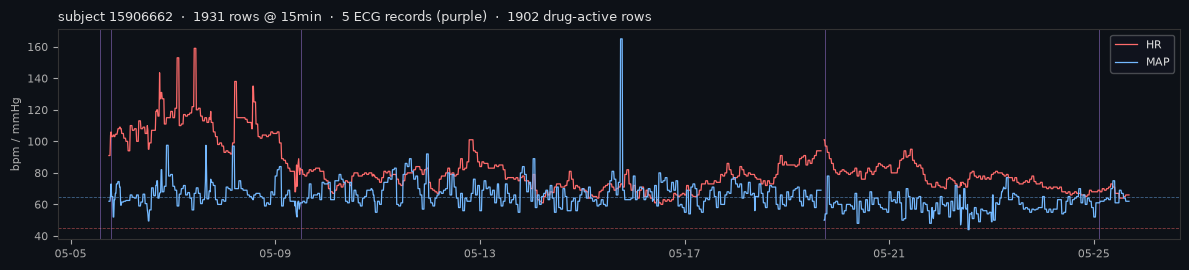

In [17]:
for patient in FINAL_PATIENTS:
    sid = patient["subject_id"]
    try:
        df = read_timeline(sid)
    except FileNotFoundError:
        print(f"⚠️  No timeline file for subject {sid} — skip plot")
        continue

    df["timestamp"] = pd.to_datetime(df["timestamp"])

    fig, ax = plt.subplots(figsize=(12, 2.8))
    ax.set_facecolor("#0d1117")
    fig.patch.set_facecolor("#0d1117")

    if "heart_rate" in df and df["heart_rate"].notna().any():
        ax.plot(df["timestamp"], df["heart_rate"],
                color="#ff6b6b", lw=0.9, label="HR", zorder=3)
    if "map" in df and df["map"].notna().any():
        ax.plot(df["timestamp"], df["map"],
                color="#74b9ff", lw=0.9, label="MAP", zorder=3)

    ax.axhline(65, color="#74b9ff", ls="--", lw=0.6, alpha=0.5)
    ax.axhline(45, color="#ff6b6b", ls="--", lw=0.6, alpha=0.5)

    if "ecg_study_id" in df:
        ecg_times = (df.dropna(subset=["ecg_study_id"])
                       .drop_duplicates(subset=["ecg_study_id"])["timestamp"])
        for t in ecg_times:
            ax.axvline(t, color="#b98cff", lw=0.6, alpha=0.5, zorder=2)

    ax.xaxis.set_major_formatter(mdates.DateFormatter("%m-%d"))
    ax.tick_params(colors="#aaaaaa", labelsize=8)
    for spine in ax.spines.values():
        spine.set_edgecolor("#333333")
    ax.set_ylabel("bpm / mmHg", color="#aaaaaa", fontsize=8)

    n_ecg  = df["ecg_study_id"].nunique() if "ecg_study_id" in df else 0
    n_drug = sum(1 for x in df.get("active_medications", []) if x not in (None, "[]", ""))
    ax.set_title(
        f"subject {sid}  ·  {len(df)} rows @ 15min  ·  "
        f"{n_ecg} ECG records (purple)  ·  {n_drug} drug-active rows",
        color="#e0e0e0", fontsize=9, loc="left")
    ax.legend(loc="upper right", fontsize=8,
              framealpha=0.3, labelcolor="#e0e0e0", facecolor="#1a1a2e")
    plt.tight_layout()
    plt.show()


---
## Done ✓

Files saved in `data/processed/patient_timelines/` (`.parquet` or `.csv` depending on your environment):

```
patient_16179553   CVICU — mitral valve + ECMO
patient_17520318   CVICU — CABG + AVR + septic shock
patient_13269747   CCU — AFib, 16 ECGs
patient_13408370   CCU — anterior MI + VF + AICD, 28 ECGs
patient_15906662   CVICU — AMI + multi-vessel CABG
```

**Next:** `04_extract_ecg_waveforms.ipynb` — extract real Lead II `.npy` waveforms for all
ECG records. Once complete, the `ecg_lead2_file` column in these timelines points to real files.
